1. Load NIfTI image using Nibabel
2. Extract affine and header information
3. Convert image data to float32
4. Reorder axes so slices come first (if needed)
5. Create SimpleITK image from NumPy array
6. Generate binary mask for foreground voxels
7. Apply N4 bias field correction
8. Convert corrected image back to NumPy array
9. Create brain mask for nonzero voxels
10. Compute mean and standard deviation of brain voxels
11. Apply z-score normalization
12. Compute 2nd and 98th percentiles for contrast stretching
13. Rescale intensity to [0, 1] range
14. Convert image to uint8 (0–255 scale)
15. Initialize CLAHE with clip limit and tile size
16. Apply CLAHE slice-by-slice in 2D
17. Stack processed slices back into 3D array
18. Revert axes to original order (if changed)
19. Create NIfTI image with original affine and header
20. Save preprocessed image to output path


### Pre-Processing
##### Percentile Stretching -- Gamma -- CLAHE -- Unsharp Masking

In [1]:
import nibabel as nib
import numpy as np
import cv2
import SimpleITK as sitk
from skimage import exposure
import os
import datetime

# # ---------- config ----------
# img_path = r"C:\Users\reval\Downloads\BRATS_21-10\TCGA-CS-4942_1997.02.22_t1.nii\TCGA-CS-4942_1997.02.22_t1.nii"
# out_path = r"C:\Users\reval\Downloads\BRATS_21-10\TCGA-CS-4942_1997.02.22_t1.nii\TCGA-CS-4942_1997.02.22_t1_enhanced.nii"
img_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz"
out_path = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced.nii.gz"

# If your 3D array has shape (slices, height, width), use SLICE_AXIS = 0
# If it has shape (height, width, slices) (rare for nibabel), use SLICE_AXIS = 2
SLICE_AXIS = 0

# CLAHE params (used for slice-wise CLAHE)
CLAHE_CLIP = 2.0
CLAHE_TILE = (8, 8)

# Choose enhancement pipeline: 'conservative' or 'aggressive'
ENHANCE_MODE = 'conservative'  # 'conservative' or 'aggressive'

# Use 3D unsharp (True) or 2D slice-wise unsharp (False)
USE_3D_UNSHARP = False

# Unsharp defaults (can be overridden depending on ENHANCE_MODE)
UNSHARP_SIGMA_2D = 1.0    # sigma in pixels for cv2.GaussianBlur when doing 2D unsharp
UNSHARP_AMOUNT_2D = 0.8   # weight for unsharp (0.5-1.0 typical)
UNSHARP_SIGMA_3D = 1.0    # sigma in mm/voxels for SimpleITK DiscreteGaussian when doing 3D unsharp
UNSHARP_AMOUNT_3D = 0.8

# Gamma defaults (will be adjusted by mode)
GAMMA = 0.9

# Misc
VERBOSE = True
# ----------------------------

# Mode-specific parameter adjustments
if ENHANCE_MODE == 'conservative':
    CLAHE_CLIP = 2.0
    CLAHE_TILE = (8, 8)
    GAMMA = 0.95
    UNSHARP_SIGMA_2D = 0.8
    UNSHARP_AMOUNT_2D = 0.6
    UNSHARP_SIGMA_3D = 0.8
    UNSHARP_AMOUNT_3D = 0.6
elif ENHANCE_MODE == 'aggressive':
    CLAHE_CLIP = 3.5
    CLAHE_TILE = (8, 8)
    GAMMA = 0.85
    UNSHARP_SIGMA_2D = 1.2
    UNSHARP_AMOUNT_2D = 1.0
    UNSHARP_SIGMA_3D = 1.2
    UNSHARP_AMOUNT_3D = 1.0
else:
    print("Unknown ENHANCE_MODE; defaulting to conservative settings.")
    CLAHE_CLIP = 2.0
    CLAHE_TILE = (8, 8)
    GAMMA = 0.95

if VERBOSE:
    print(f"[{datetime.datetime.now()}] Starting preprocessing with ENHANCE_MODE={ENHANCE_MODE}, USE_3D_UNSHARP={USE_3D_UNSHARP}")

# ---------- 1) load using nibabel (keep affine/header for saving) ----------
img_nifti = nib.load(img_path)
affine = img_nifti.affine
header = img_nifti.header
img_data = img_nifti.get_fdata().astype(np.float32)  # float32 for processing

# Optionally reorder so slices are first axis: we want an array of shape (slices, H, W)
if SLICE_AXIS != 0:
    img_data = np.moveaxis(img_data, SLICE_AXIS, 0)

# ---------- 2) N4 Bias Field Correction ----------
# SimpleITK expects array shaped (z,y,x) which matches slices-first ordering
sitk_img = sitk.GetImageFromArray(img_data)                       # float32
sitk_img = sitk.Cast(sitk_img, sitk.sitkFloat32)

# Create a crude mask to speed N4 and protect background (optional but recommended)
mask_np = (img_data > 0).astype(np.uint8)
mask_sitk = sitk.GetImageFromArray(mask_np)
mask_sitk = sitk.Cast(mask_sitk, sitk.sitkUInt8)

if VERBOSE:
    print(f"[{datetime.datetime.now()}] Running N4BiasFieldCorrection ... (this can take a while)")

corrected_sitk = sitk.N4BiasFieldCorrection(sitk_img, mask_sitk)
img_corrected = sitk.GetArrayFromImage(corrected_sitk).astype(np.float32)

# ---------- 3) Z-score normalization — compute mean/std only over non-zero (brain) voxels ----------
brain_mask = img_corrected > 0
if np.any(brain_mask):
    mean_val = img_corrected[brain_mask].mean()
    std_val = img_corrected[brain_mask].std()
else:
    mean_val = img_corrected.mean()
    std_val = img_corrected.std()

if std_val == 0 or np.isnan(std_val):
    std_val = 1.0

img_norm = (img_corrected - mean_val) / std_val

# Keep background zero
img_norm[~brain_mask] = 0.0

# ---------- 4) Contrast stretching using percentiles computed on brain voxels ----------
if np.any(brain_mask):
    p2, p98 = np.percentile(img_norm[brain_mask], (2, 98))
else:
    p2, p98 = np.percentile(img_norm, (2, 98))

# Avoid degenerate percentile range
if p98 == p2:
    p2, p98 = img_norm.min(), img_norm.max()
    if p98 == p2:
        p2 -= 1.0
        p98 += 1.0

img_stretched = exposure.rescale_intensity(img_norm, in_range=(p2, p98), out_range=(0.0, 1.0))
img_stretched[~brain_mask] = 0.0

# ---------- 5) Gamma correction (on brain voxels only) ----------
img_gamma = np.copy(img_stretched)
if np.any(brain_mask):
    img_gamma[brain_mask] = np.power(img_stretched[brain_mask], GAMMA)
else:
    img_gamma = np.power(img_stretched, GAMMA)
img_gamma[~brain_mask] = 0.0

# ---------- 6) Unsharp mask (2D slice-wise or 3D) ----------
if USE_3D_UNSHARP:
    # 3D unsharp using SimpleITK DiscreteGaussian smoothing
    if VERBOSE:
        print(f"[{datetime.datetime.now()}] Applying 3D unsharp (SimpleITK DiscreteGaussian) ...")
    # convert to sitk image
    sitk_float = sitk.GetImageFromArray(img_gamma)
    sitk_float = sitk.Cast(sitk_float, sitk.sitkFloat32)
    # apply DiscreteGaussian smoothing (sigma in voxel units)
    smoothed = sitk.DiscreteGaussian(sitk_float, variance=UNSHARP_SIGMA_3D**2)
    smoothed_np = sitk.GetArrayFromImage(smoothed).astype(np.float32)
    # unsharp: res = (1+amount)*orig - amount*smoothed
    img_unsharp = (1.0 + UNSHARP_AMOUNT_3D) * img_gamma - UNSHARP_AMOUNT_3D * smoothed_np
    img_unsharp = np.clip(img_unsharp, 0.0, 1.0)
    img_unsharp[~brain_mask] = 0.0
else:
    # 2D slice-wise unsharp using cv2 GaussianBlur on float slices
    if VERBOSE:
        print(f"[{datetime.datetime.now()}] Applying 2D slice-wise unsharp (cv2 GaussianBlur) ...")
    slices = img_gamma.shape[0]
    img_unsharp = np.zeros_like(img_gamma, dtype=np.float32)
    for i in range(slices):
        src = img_gamma[i]
        if np.all(src == 0):
            img_unsharp[i] = src
        else:
            # cv2.GaussianBlur supports float32; pass ksize=(0,0) to infer kernel from sigma
            blurred = cv2.GaussianBlur(src.astype(np.float32), ksize=(0, 0),
                                       sigmaX=UNSHARP_SIGMA_2D, sigmaY=UNSHARP_SIGMA_2D,
                                       borderType=cv2.BORDER_REPLICATE)
            res = cv2.addWeighted(src.astype(np.float32), 1.0 + UNSHARP_AMOUNT_2D, blurred, -UNSHARP_AMOUNT_2D, 0.0)
            res = np.clip(res, 0.0, 1.0)
            # Keep background zero
            if np.any(brain_mask[i] == False):
                res[np.logical_not(brain_mask[i])] = 0.0
            img_unsharp[i] = res

# ---------- 7) Convert to uint8 and apply CLAHE slice-wise ----------
if VERBOSE:
    print(f"[{datetime.datetime.now()}] Converting to uint8 and applying CLAHE (clip={CLAHE_CLIP}, tile={CLAHE_TILE}) ...")
img_uint8 = (img_unsharp * 255.0).clip(0, 255).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

slices = img_uint8.shape[0]
clahe_slices = []
for i in range(slices):
    img_slice = img_uint8[i]
    if np.all(img_slice == 0):
        clahe_slices.append(img_slice)
    else:
        # Optionally, you can restrict CLAHE to brain region by masking; here we apply to whole slice
        clahe_slice = clahe.apply(img_slice)
        # re-mask background to zero (avoid background enhancement/artifacts)
        if np.any(~brain_mask[i]):
            clahe_slice[np.logical_not(brain_mask[i])] = 0
        clahe_slices.append(clahe_slice)

img_clahe = np.stack(clahe_slices, axis=0).astype(np.uint8)

# ---------- 8) Move axes back to original orientation if needed, and save ----------
if SLICE_AXIS != 0:
    img_clahe = np.moveaxis(img_clahe, 0, SLICE_AXIS)

# Ensure output directory exists
out_dir = os.path.dirname(out_path)
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir, exist_ok=True)

# Save as NIfTI using original affine and header (we use uint8 data)
out_fname = out_path
# add mode tag to filename if not already present
base, ext = os.path.splitext(out_fname)
if ext == '.gz':
    base2, ext2 = os.path.splitext(base)
    ext = ext2 + ext
    base = base2
tag = f"_{ENHANCE_MODE}"
if USE_3D_UNSHARP:
    tag += "_3Dunsharp"
else:
    tag += "_2Dunsharp"
out_fname = base + tag + ext

out_img = nib.Nifti1Image(img_clahe, affine, header=header)
out_img.set_data_dtype(np.uint8)
nib.save(out_img, out_fname)

if VERBOSE:
    print(f"[{datetime.datetime.now()}] Saved enhanced image to: {out_fname}")
    print(f"[{datetime.datetime.now()}] Done.")


[2025-10-22 11:16:13.177755] Starting preprocessing with ENHANCE_MODE=conservative, USE_3D_UNSHARP=False
[2025-10-22 11:16:13.608423] Running N4BiasFieldCorrection ... (this can take a while)
[2025-10-22 11:18:08.135433] Applying 2D slice-wise unsharp (cv2 GaussianBlur) ...
[2025-10-22 11:18:08.189811] Converting to uint8 and applying CLAHE (clip=2.0, tile=(8, 8)) ...
[2025-10-22 11:18:08.598268] Saved enhanced image to: D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz
[2025-10-22 11:18:08.598268] Done.


## METRICS 

In [3]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from skimage import exposure, filters
from scipy.ndimage import gaussian_filter
import SimpleITK as sitk
import os

# # ============================================================
# # STEP 1: PREPROCESSING
# # ============================================================

# def n4_bias_correction(img_data):
#     sitk_img = sitk.GetImageFromArray(img_data)
#     mask_image = sitk.OtsuThreshold(sitk_img, 0, 1, 200)
#     corrector = sitk.N4BiasFieldCorrectionImageFilter()
#     sitk_corrected = corrector.Execute(sitk_img, mask_image)
#     return sitk.GetArrayFromImage(sitk_corrected)

# def preprocess_image(filepath):
#     print("============================================================")
#     print("STEP 1: PREPROCESSING THE IMAGE")
#     print("============================================================\n")

#     print("1. Loading image...")
#     img = nib.load(filepath)
#     data = img.get_fdata().astype(np.float32)
#     print(f"   Image shape: {data.shape}\n")

#     print("2. Running N4 Bias Field Correction...")
#     corrected = n4_bias_correction(data)

#     print("\n3. Creating robust brain mask and normalizing...")
#     mask = corrected > np.percentile(corrected, 50)
#     brain = corrected[mask]
#     corrected_norm = np.zeros_like(corrected)
#     corrected_norm[mask] = (brain - brain.min()) / (brain.max() - brain.min() + 1e-8)
#     print(f"✅ Brain voxels: {np.count_nonzero(mask)} / {np.prod(mask.shape)}")

#     print("\n4. Applying contrast stretching...")
#     p2, p98 = np.percentile(corrected_norm[mask], (2, 98))
#     stretched = exposure.rescale_intensity(corrected_norm, in_range=(p2, p98))

#     print("\n5. Applying gamma correction...")
#     gamma_corrected = exposure.adjust_gamma(stretched, gamma=1.2)

#     print("\n6. Applying unsharp masking...")
#     blurred = gaussian_filter(gamma_corrected, sigma=1)
#     unsharp = np.clip(gamma_corrected + (gamma_corrected - blurred), 0, 1)

#     print("\n7. Applying CLAHE...")
#     clahe = exposure.equalize_adapthist(unsharp, clip_limit=0.03)

#     print("\n✓ Preprocessing complete!\n")

#     return clahe, mask, img.affine, img.header

# ============================================================
# STEP 2: ROI EXTRACTION
# ============================================================

def extract_roi(data, center, size=(40, 40)):
    x, y = center
    x1, x2 = max(0, x - size[0]//2), min(data.shape[0], x + size[0]//2)
    y1, y2 = max(0, y - size[1]//2), min(data.shape[1], y + size[1]//2)
    roi = data[x1:x2, y1:y2]
    return roi

def ensure_valid_roi(roi, data):
    if np.count_nonzero(roi) == 0:
        # Move to a region with non-zero intensity (brain area)
        nonzero = np.argwhere(data > 0.1)
        if len(nonzero) > 0:
            cx, cy, _ = np.median(nonzero, axis=0).astype(int)
            roi = extract_roi(data[:, :, data.shape[2]//2], (cx, cy))
    return roi

def get_rois(enhanced):
    print("============================================================")
    print("STEP 2: EXTRACTING ROIs")
    print("============================================================\n")

    mid_slice = enhanced[:, :, enhanced.shape[2] // 2]

    # ROI centers (can be adjusted based on dataset)
    tumor_center = (120, 120)
    wm_center = (70, 70)
    gm_center = (160, 160)
    bg_center = (30, 30)

    tumor = extract_roi(mid_slice, tumor_center)
    wm = extract_roi(mid_slice, wm_center, size=(40, 5))
    gm = extract_roi(mid_slice, gm_center)
    bg = extract_roi(mid_slice, bg_center, size=(30, 30))

    # Ensure no empty ROIs
    tumor = ensure_valid_roi(tumor, mid_slice)
    wm = ensure_valid_roi(wm, mid_slice)
    gm = ensure_valid_roi(gm, mid_slice)
    bg = ensure_valid_roi(bg, mid_slice)

    rois = {"Tumor": tumor, "White Matter": wm, "Gray Matter": gm, "Background": bg}

    print("--- ROI Diagnostics ---")
    for name, roi in rois.items():
        print(f"{name}: mean={roi.mean():.3f}, std={roi.std():.3f}, shape={roi.shape}")

    print()
    return rois

# ============================================================
# STEP 3: SNR AND CNR CALCULATION
# ============================================================

def compute_snr_cnr(rois):
    print("============================================================")
    print("STEP 3: CALCULATING SNR AND CNR")
    print("============================================================\n")

    means = np.array([rois[k].mean() for k in ["Tumor", "White Matter", "Gray Matter"]])
    stds = np.array([rois[k].std() for k in ["Tumor", "White Matter", "Gray Matter"]])
    stds = np.where(stds == 0, 1e-6, stds)  # avoid division by zero

    snr = means / stds

    cnr12 = abs(means[0] - means[1]) / np.mean([stds[0], stds[1]])
    cnr13 = abs(means[0] - means[2]) / np.mean([stds[0], stds[2]])
    cnr23 = abs(means[1] - means[2]) / np.mean([stds[1], stds[2]])

    print("--- SNR ---")
    for i, name in enumerate(["Tumor", "White Matter", "Gray Matter"]):
        print(f"ROI {i+1} ({name}): {snr[i]:.3f}")

    print("\n--- CNR ---")
    print(f"ROI 1 vs ROI 2: {cnr12:.3f}")
    print(f"ROI 1 vs ROI 3: {cnr13:.3f}")
    print(f"ROI 2 vs ROI 3: {cnr23:.3f}\n")

    return snr, [cnr12, cnr13, cnr23]

# ============================================================
# STEP 4: SAVE RESULTS AND VISUALIZATION
# ============================================================

def save_results(enhanced, affine, header, rois, snr, cnr, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    nii_out = os.path.join(out_dir, "enhanced_image.nii.gz")
    nib.save(nib.Nifti1Image(enhanced, affine, header), nii_out)
    print(f"✓ Saved enhanced image: {nii_out}")

    # Save metrics
    txt_out = os.path.join(out_dir, "roi_metrics.txt")
    with open(txt_out, "w") as f:
        for name, roi in rois.items():
            f.write(f"{name}: mean={roi.mean():.3f}, std={roi.std():.3f}\n")
        f.write("\nSNR:\n")
        for i, val in enumerate(snr):
            f.write(f"ROI {i+1}: {val:.3f}\n")
        f.write("\nCNR:\n")
        for val in cnr:
            f.write(f"{val:.3f}\n")
    print(f"✓ Saved metrics: {txt_out}")

    # Visualization
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    mid_slice = enhanced[:, :, enhanced.shape[2] // 2]
    ax.imshow(mid_slice, cmap='gray')
    colors = {'Tumor': 'r', 'White Matter': 'y', 'Gray Matter': 'b', 'Background': 'g'}
    centers = {'Tumor': (120, 120), 'White Matter': (70, 70),
               'Gray Matter': (160, 160), 'Background': (30, 30)}

    for name, (x, y) in centers.items():
        ax.add_patch(plt.Rectangle((y-20, x-20), 40, 40, fill=False, edgecolor=colors[name], lw=2))
        ax.text(y-25, x-25, name, color=colors[name], fontsize=8, backgroundcolor='k')

    out_path = os.path.join(out_dir, "roi_visualization.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"✓ Saved visualization: {out_path}\n")

# ============================================================
# MAIN EXECUTION
# ============================================================

if __name__ == "__main__":
    filepath = r"C:\Users\indir\OneDrive\Documents\Medical_imaging\TCGA-CS-4942_1997.02.22_t1.nii.gz"
    output_dir = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_metrics"

    enhanced, mask, affine, header = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
    rois = get_rois(enhanced)
    snr, cnr = compute_snr_cnr(rois)
    save_results(enhanced, affine, header, rois, snr, cnr, output_dir)

    print("============================================================")
    print("ALL DONE! ✓")
    print("============================================================")

ValueError: too many values to unpack (expected 4)

### Reference Mask

In [5]:
import numpy as np
import nibabel as nib
from scipy import ndimage as ndi

# --- File paths ---
img_path = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"

# --- Load images ---
img_nifti = nib.load(img_path)
img = img_nifti.get_fdata().astype(np.float32)
affine = img_nifti.affine

tumor_mask_nifti = nib.load(tumor_mask_path)
tumor_mask = tumor_mask_nifti.get_fdata()
tumor_mask = (tumor_mask > 0)  # Convert multi-label to binary

# --- Create brain mask from image (simple threshold) ---
brain_mask = img > 0  # assuming nonzero voxels are brain

# --- 1. Find tumor centroid ---
coords = np.argwhere(tumor_mask)
if coords.size == 0:
    raise ValueError("Tumor mask is empty! Check your segmentation file.")
centroid = coords.mean(axis=0).astype(int)
print("Tumor centroid:", centroid)

# --- 2. Compute midline along left-right axis (last axis) ---
brain_coords = np.argwhere(brain_mask)
midline = brain_coords[:, -1].mean()
print("Midline x-coordinate:", midline)

# --- 3. Mirror centroid across midline ---
mirror_centroid = centroid.copy()
mirror_centroid[-1] = int(midline - (centroid[-1] - midline))
print("Reference region centroid:", mirror_centroid)

# --- 4. Create small cube around mirror_centroid ---
radius = 5  # voxels
ref_mask = np.zeros_like(tumor_mask, dtype=bool)
mins = np.maximum(mirror_centroid - radius, 0)
maxs = np.minimum(mirror_centroid + radius + 1, np.array(tumor_mask.shape))
ref_mask[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]] = True

# --- 5. Restrict to brain ---
ref_mask = np.logical_and(ref_mask, brain_mask)

# # --- Optional: save reference mask ---
# nib.save(nib.Nifti1Image(ref_mask.astype(np.uint8), affine), 
#          r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-4942_refMask.nii.gz")

# print("Reference mask created and saved.")


Tumor centroid: [ 87 119  76]
Midline x-coordinate: 71.8253934929086
Reference region centroid: [ 87 119  67]


✅ Significance of this reference mask:

This is not tumor.

It represents the same approximate location in the opposite hemisphere.

Useful for:

Comparing tumor vs normal tissue intensity or texture.

Feature extraction (e.g., difference between tumor and healthy mirror region).

This is exactly why the green contour is plotted in your visualization: it shows the reference region opposite to the tumor.

### Noise Mask

In [6]:
# 1. Invert brain mask
inv_brain = np.logical_not(brain_mask)

# 2. Use distance transform to pick a voxel farthest from brain (deepest air)
dt = ndi.distance_transform_edt(inv_brain)
maxpos = np.unravel_index(np.argmax(dt), dt.shape)

# 3. Create small cuboid around that voxel
radius = 5
noise_mask = np.zeros_like(tumor_mask, dtype=bool)
mins = np.maximum(np.array(maxpos) - radius, 0)
maxs = np.minimum(np.array(maxpos) + radius + 1, np.array(tumor_mask.shape))
noise_mask[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]] = True


### Tumor Isolation

Image shape: (240, 240, 155)
Tumor mask shape: (240, 240, 155)
Reference mask shape: (240, 240, 155)
Visualizing axial slice: 77


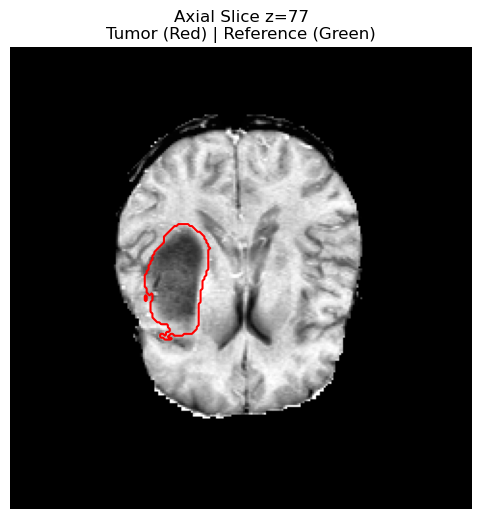

In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ---- Load MRI and tumor mask ----
img_path = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"

img = nib.load(img_path)
data = img.get_fdata()
tumor_mask = nib.load(tumor_mask_path).get_fdata() > 0  # convert to binary mask

# ---- Assume ref_mask is already in memory ----
# Example:
# ref_mask = np.load(r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-4942_refMask.npy")
# OR from your earlier code, you already created it:
# ref_mask = <your array>

# Sanity check
print("Image shape:", data.shape)
print("Tumor mask shape:", tumor_mask.shape)
print("Reference mask shape:", ref_mask.shape)

# ---- Pick an axial slice (z-direction) ----
z = data.shape[2] // 2  # center slice
print("Visualizing axial slice:", z)

# ---- Extract 2D slices ----
img_slice = np.rot90(data[:, :, z])
tumor_slice = np.rot90(tumor_mask[:, :, z])
ref_slice = np.rot90(ref_mask[:, :, z])

# ---- Visualization ----
plt.figure(figsize=(6, 6))
plt.imshow(img_slice, cmap='gray', origin='upper')

# Option 1: Contour outlines (clean look)
plt.contour(tumor_slice, levels=[0.5], colors='r', linewidths=1.5)
plt.contour(ref_slice, levels=[0.5], colors='g', linewidths=1.5)

# Option 2 (optional): Transparent overlays — comment out if not needed
# plt.imshow(np.ma.masked_where(~tumor_slice, tumor_slice), cmap='Reds', alpha=0.4)
# plt.imshow(np.ma.masked_where(~ref_slice, ref_slice), cmap='Greens', alpha=0.4)

plt.title(f"Axial Slice z={z}\nTumor (Red) | Reference (Green)")
plt.axis('off')
plt.show()


Image shape: (240, 240, 155)
Tumor mask shape: (240, 240, 155)
Reference mask shape: (240, 240, 155)
Visualizing axial slice with max tumor voxels at z = 76


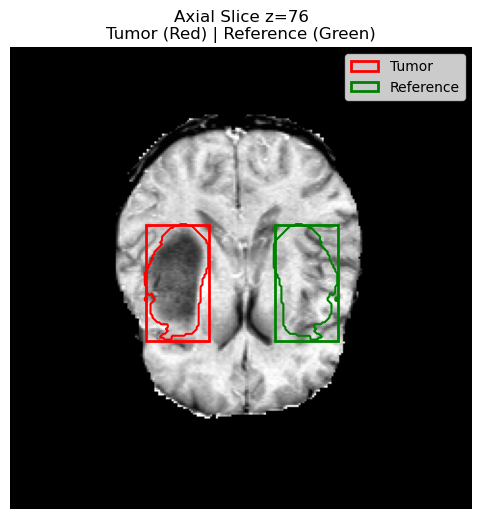

In [8]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---- Load MRI and tumor mask ----
img_path =r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"

# Load data
img = nib.load(img_path)
data = img.get_fdata()
tumor_mask = nib.load(tumor_mask_path).get_fdata() > 0

# ---- Generate reference mask by mirroring tumor mask ----
ref_mask = np.flip(tumor_mask, axis=0)  # mirror along left-right axis

# ---- Sanity check ----
print("Image shape:", data.shape)
print("Tumor mask shape:", tumor_mask.shape)
print("Reference mask shape:", ref_mask.shape)

# ---- Choose slice with maximum tumor voxels ----
tumor_counts = tumor_mask.sum(axis=(0, 1))
z = int(np.argmax(tumor_counts))
print("Visualizing axial slice with max tumor voxels at z =", z)

# ---- Extract 2D slices and rotate for display ----
img_slice = np.rot90(data[:, :, z])
tumor_slice = np.rot90(tumor_mask[:, :, z])
ref_slice = np.rot90(ref_mask[:, :, z])

# ---- Bounding box helper ----
def bbox_from_mask2d(mask2d):
    coords = np.argwhere(mask2d)
    if coords.size == 0:
        return None
    rmin, cmin = coords.min(axis=0)
    rmax, cmax = coords.max(axis=0)
    return (rmin, cmin, rmax, cmax)

# ---- Compute bounding boxes ----
tumor_bb = bbox_from_mask2d(tumor_slice)
ref_bb = bbox_from_mask2d(ref_slice)

# ---- Visualization ----
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_slice, cmap='gray', origin='upper')

# Contour outlines
if tumor_slice.sum() > 0:
    ax.contour(tumor_slice, levels=[0.5], colors='r', linewidths=1.5)
if ref_slice.sum() > 0:
    ax.contour(ref_slice, levels=[0.5], colors='g', linewidths=1.5)

# Bounding boxes
if tumor_bb is not None:
    rmin, cmin, rmax, cmax = tumor_bb
    ax.add_patch(patches.Rectangle((cmin, rmin), cmax - cmin + 1, rmax - rmin + 1,
                                   linewidth=2, edgecolor='r', facecolor='none', label='Tumor'))

if ref_bb is not None:
    rmin, cmin, rmax, cmax = ref_bb
    ax.add_patch(patches.Rectangle((cmin, rmin), cmax - cmin + 1, rmax - rmin + 1,
                                   linewidth=2, edgecolor='g', facecolor='none', label='Reference'))

# Final touches
ax.set_title(f"Axial Slice z={z}\nTumor (Red) | Reference (Green)")
ax.axis('off')
ax.legend(loc='upper right')
plt.show()


### Segmentation

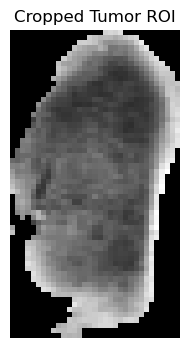


--- Tumor ROI Intensity Features ---
Pixel Count       : 1409
Mean Intensity    : 117.87
Std Dev Intensity : 49.89
Skewness          : 0.78
Kurtosis          : -0.45
✅ Saved segmented tumor as 3D NIfTI: tumor_roi_3D_volume.nii.gz


In [9]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import skew, kurtosis
import os

# ---- Load MRI and tumor mask ----
img_path = r"D:\MI_BRATS\Output_PreProcessed\TCGA-CS-49422_1997.02.22_t1_enhanced_conservative_2Dunsharp.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"

img = nib.load(img_path)
data = img.get_fdata()
tumor_mask = nib.load(tumor_mask_path).get_fdata() > 0

# ---- Mirror tumor mask to create reference ----
ref_mask = np.flip(tumor_mask, axis=0)

# ---- Choose slice with max tumor voxels ----
tumor_counts = tumor_mask.sum(axis=(0, 1))
z = int(np.argmax(tumor_counts))

# ---- Extract and rotate slices ----
img_slice = np.rot90(data[:, :, z])
tumor_slice = np.rot90(tumor_mask[:, :, z])
ref_slice = np.rot90(ref_mask[:, :, z])

# ---- Bounding box helper ----
def bbox_from_mask2d(mask2d):
    coords = np.argwhere(mask2d)
    if coords.size == 0:
        return None
    rmin, cmin = coords.min(axis=0)
    rmax, cmax = coords.max(axis=0)
    return (rmin, cmin, rmax, cmax)

tumor_bb = bbox_from_mask2d(tumor_slice)

# ---- Segment tumor ROI ----
tumor_roi = img_slice * tumor_slice  # apply mask

if tumor_bb is not None:
    rmin, cmin, rmax, cmax = tumor_bb
    cropped_roi = tumor_roi[rmin:rmax+1, cmin:cmax+1]
else:
    cropped_roi = None

# ---- Visualize segmented ROI ----
if cropped_roi is not None:
    plt.figure(figsize=(4, 4))
    plt.imshow(cropped_roi, cmap='gray', interpolation='none')
    plt.title("Cropped Tumor ROI")
    plt.axis('off')
    plt.show()

# ---- Extract intensity features ----
if cropped_roi is not None and np.any(cropped_roi):
    roi_pixels = cropped_roi[cropped_roi > 0]
    mean_intensity = np.mean(roi_pixels)
    std_intensity = np.std(roi_pixels)
    skewness = skew(roi_pixels)
    kurt = kurtosis(roi_pixels)
    pixel_count = roi_pixels.size

    print("\n--- Tumor ROI Intensity Features ---")
    print(f"Pixel Count       : {pixel_count}")
    print(f"Mean Intensity    : {mean_intensity:.2f}")
    print(f"Std Dev Intensity : {std_intensity:.2f}")
    print(f"Skewness          : {skewness:.2f}")
    print(f"Kurtosis          : {kurt:.2f}")
else:
    print("No valid tumor ROI found for feature extraction.")

# ---- Save segmented tumor as 3D NIfTI ----
output_dir = r"D:\MI_BRATS\Output_Features"
os.makedirs(output_dir, exist_ok=True)

if cropped_roi is not None and np.any(cropped_roi):
    # Create a 3D volume with tumor ROI only in slice z
    tumor_3d = np.zeros_like(data, dtype=np.float32)
    tumor_3d[:, :, z] = tumor_mask[:, :, z] * data[:, :, z]  # apply mask to original slice

    # Save as 3D NIfTI
    tumor_3d_nifti = nib.Nifti1Image(tumor_3d, affine=img.affine)
    nib.save(tumor_3d_nifti, os.path.join(output_dir, "tumor_roi_3D_volume.nii.gz"))
    print("✅ Saved segmented tumor as 3D NIfTI: tumor_roi_3D_volume.nii.gz")


### Save the segmented tumor region in 3D as Nifti

In [10]:
# ---- Apply full 3D tumor mask to original image ----
tumor_3d = data * tumor_mask.astype(np.float32)

# ---- Save as 3D NIfTI ----
tumor_3d_nifti = nib.Nifti1Image(tumor_3d, affine=img.affine)
nib.save(tumor_3d_nifti, os.path.join(output_dir, "tumor_roi_full_3D_volume.nii.gz"))
print("✅ Saved full 3D tumor ROI volume with original intensities.")


✅ Saved full 3D tumor ROI volume with original intensities.


### Segmentation into Tumor Core, Enhancing Tumor and Edema
##### Multi-file labeled segmentation

In [14]:
import nibabel as nib
import numpy as np
import os

# ---- Load modalities ----
t1_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz"
t1gd_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1Gd.nii.gz"
flair_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_flair.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"


t1 = nib.load(t1_path).get_fdata()
t1gd = nib.load(t1gd_path).get_fdata()
flair = nib.load(flair_path).get_fdata()
tumor_mask = nib.load(tumor_mask_path).get_fdata() > 0
affine = nib.load(t1_path).affine

# ---- Apply tumor mask to each modality ----
t1_roi = t1 * tumor_mask
t1gd_roi = t1gd * tumor_mask
flair_roi = flair * tumor_mask

# ---- Define thresholds (tune these empirically) ----
t1gd_thresh = np.percentile(t1gd_roi[t1gd_roi > 0], 85)  # high intensity in T1-Gd
flair_thresh = np.percentile(flair_roi[flair_roi > 0], 85)  # high intensity in FLAIR

# ---- Segment subregions ----
enhancing_mask = (t1gd_roi > t1gd_thresh)
edema_mask = (flair_roi > flair_thresh) & (~enhancing_mask)
core_mask = tumor_mask & (~edema_mask)

# ---- Save masks ----
output_dir = r"D:\MI_BRATS\Output_Subregions"
os.makedirs(output_dir, exist_ok=True)

nib.save(nib.Nifti1Image(enhancing_mask.astype(np.uint8), affine), os.path.join(output_dir, "enhancing_tumor.nii.gz"))
nib.save(nib.Nifti1Image(core_mask.astype(np.uint8), affine), os.path.join(output_dir, "tumor_core.nii.gz"))
nib.save(nib.Nifti1Image(edema_mask.astype(np.uint8), affine), os.path.join(output_dir, "peritumoral_edema.nii.gz"))

print("✅ Saved subregion masks: enhancing_tumor, tumor_core, peritumoral_edema")


✅ Saved subregion masks: enhancing_tumor, tumor_core, peritumoral_edema


##### Single file multi-Label segmentation

In [25]:
import nibabel as nib
import numpy as np
import os

# ---- Load modalities ----
t1_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1.nii.gz"
t1gd_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t1Gd.nii.gz"
flair_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_flair.nii.gz"
tumor_mask_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_GlistrBoost.nii.gz"
t2_path = r"D:\MI_BRATS\Pre-operative_TCGA_LGG_NIfTI_and_Segmentations\TCGA-CS-4942\TCGA-CS-4942_1997.02.22_t2.nii.gz"

# ---- Load images ----
t1 = nib.load(t1_path).get_fdata()
t2 = nib.load(t2_path).get_fdata()
t1gd = nib.load(t1gd_path).get_fdata()
flair = nib.load(flair_path).get_fdata()
tumor_mask = nib.load(tumor_mask_path).get_fdata() > 0
affine = nib.load(t1_path).affine

# ---- Apply tumor mask ----
t1gd_roi = t1gd * tumor_mask
flair_roi = flair * tumor_mask

# ---- Define thresholds ----
t1gd_thresh = np.percentile(t1gd_roi[t1gd_roi > 0], 85)
flair_thresh = np.percentile(flair_roi[flair_roi > 0], 85)

# ---- Segment subregions ----
enhancing_mask = (t1gd_roi > t1gd_thresh)
edema_mask = (flair_roi > flair_thresh) & (~enhancing_mask)
core_mask = tumor_mask & (~edema_mask)

# ---- Create combined labeled mask ----
# Label scheme:
# 0 = background
# 1 = peritumoral edema
# 2 = tumor core (non-enhancing)
# 3 = enhancing tumor

labeled_mask = np.zeros_like(tumor_mask, dtype=np.uint8)
labeled_mask[edema_mask] = 1
labeled_mask[core_mask] = 2
labeled_mask[enhancing_mask] = 3

# ---- Save single labeled NIfTI ----
output_dir = r"D:\MI_BRATS\Output_Subregions"
os.makedirs(output_dir, exist_ok=True)

labeled_path = os.path.join(output_dir, "tumor_labeled_mask.nii.gz")
nib.save(nib.Nifti1Image(labeled_mask, affine), labeled_path)

print("✅ Saved combined labeled mask at:", labeled_path)


✅ Saved combined labeled mask at: D:\MI_BRATS\Output_Subregions\tumor_labeled_mask.nii.gz


### Feature Extraction

##### Intensity Stats Across Modalities and Subregions
It is computing histogram-based features from the raw image, within the segmented region.

In [19]:
from scipy.stats import skew, kurtosis
import numpy as np

def extract_intensity_stats(img, mask, bins=50):
    """Extract intensity-based statistics from a masked region in a given modality"""
    region = img[mask > 0]
    if region.size == 0:
        return {
            "Mean": 0, "Median": 0, "Std": 0, "Variance": 0,
            "Min": 0, "Max": 0, "Skewness": 0, "Kurtosis": 0,
            "10th Percentile": 0, "25th Percentile": 0,
            "75th Percentile": 0, "90th Percentile": 0,
            "Entropy": 0
        }

    hist, _ = np.histogram(region, bins=bins, density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist))

    return {
        "Mean": np.mean(region),
        "Median": np.median(region),
        "Std": np.std(region),
        "Variance": np.var(region),
        "Min": np.min(region),
        "Max": np.max(region),
        "Skewness": skew(region),
        "Kurtosis": kurtosis(region),
        "10th Percentile": np.percentile(region, 10),
        "25th Percentile": np.percentile(region, 25),
        "75th Percentile": np.percentile(region, 75),
        "90th Percentile": np.percentile(region, 90),
        "Entropy": entropy
    }

modalities = {
    "T1": t1,
    "T1-Gd": t1gd,
    "FLAIR": flair
}

subregions = {
    "Enhancing Tumor": enhancing_mask,
    "Tumor Core": core_mask,
    "Peritumoral Edema": edema_mask
}

print("\n===== Intensity-Based Statistics Across Modalities =====\n")
for region_name, mask in subregions.items():
    print(f"--- {region_name} ---")
    for modality_name, img in modalities.items():
        stats = extract_intensity_stats(img, mask)
        print(f"\n{modality_name} stats:")
        for k, v in stats.items():
            print(f"{k}: {v:.3f}")
    print("\n" + "-"*50 + "\n")



===== Intensity-Based Statistics Across Modalities =====

--- Enhancing Tumor ---

T1 stats:
Mean: 1362.727
Median: 1370.000
Std: 70.231
Variance: 4932.324
Min: 1058.000
Max: 1524.000
Skewness: -0.771
Kurtosis: 1.044
10th Percentile: 1273.000
25th Percentile: 1325.000
75th Percentile: 1409.000
90th Percentile: 1445.000
Entropy: 0.869

T1-Gd stats:
Mean: 1303.636
Median: 1289.000
Std: 44.558
Variance: 1985.450
Min: 1260.000
Max: 1651.000
Skewness: 1.912
Kurtosis: 5.105
10th Percentile: 1264.000
25th Percentile: 1272.000
75th Percentile: 1319.000
90th Percentile: 1367.000
Entropy: 0.880

FLAIR stats:
Mean: 1330.745
Median: 1269.000
Std: 232.132
Variance: 53885.333
Min: 802.000
Max: 2198.000
Skewness: 1.108
Kurtosis: 0.964
10th Percentile: 1098.000
25th Percentile: 1168.000
75th Percentile: 1443.000
90th Percentile: 1673.200
Entropy: 0.347

--------------------------------------------------

--- Tumor Core ---

T1 stats:
Mean: 1141.146
Median: 1129.000
Std: 163.456
Variance: 26717.862
Mi

##### Geometric Stats Across Subregions

In [20]:
import numpy as np
from scipy import ndimage as ndi
from skimage import measure
from skimage.measure import marching_cubes, mesh_surface_area

def extract_geometric_features(mask, voxel_spacing=(1.0, 1.0, 1.0)):
    """Extract geometric features from a 3D binary mask"""
    mask = (mask > 0).astype(np.uint8)
    label_img, num_labels = ndi.label(mask)
    if num_labels == 0:
        return {
            "Volume (voxels)": 0,
            "Volume (mm³)": 0,
            "Surface area (mm²)": 0,
            "Compactness": 0,
            "Elongation": 0,
            "Centroid": (0, 0, 0),
            "Bounding box": (0, 0, 0, 0, 0, 0)
        }

    region = max(measure.regionprops(label_img), key=lambda r: r.area)

    # Volume
    volume_voxels = region.area
    volume_mm3 = volume_voxels * np.prod(voxel_spacing)

    # Centroid and bounding box
    centroid = region.centroid
    bbox = region.bbox

    # Axis lengths
    major_axis = region.major_axis_length
    minor_axis = region.minor_axis_length
    elongation = major_axis / minor_axis if minor_axis != 0 else 0

    # Surface area via marching cubes
    verts, faces, _, _ = marching_cubes(mask, level=0.5, spacing=voxel_spacing)
    surface_area = mesh_surface_area(verts, faces)

    # Compactness: normalized volume-to-surface ratio
    compactness = (volume_mm3 ** (2/3)) / surface_area if surface_area != 0 else 0

    return {
        "Volume (voxels)": volume_voxels,
        "Volume (mm³)": volume_mm3,
        "Surface area (mm²)": surface_area,
        "Compactness": compactness,
        "Elongation": elongation,
        "Centroid": centroid,
        "Bounding box": bbox
    }

print("\n===== Geometric Features for Tumor Subregions =====\n")
for region_name, mask in subregions.items():
    print(f"--- {region_name} ---")
    geo_features = extract_geometric_features(mask, voxel_spacing=(1.0, 1.0, 1.0))  # update spacing if known
    for k, v in geo_features.items():
        print(f"{k}: {v}")
    print("\n" + "-"*50 + "\n")


===== Geometric Features for Tumor Subregions =====

--- Enhancing Tumor ---
Volume (voxels): 6926.0
Volume (mm³): 6926.0
Surface area (mm²): 10400.9228515625
Compactness: 0.034934118019979025
Elongation: 2.703364083431177
Centroid: (94.80594859948022, 116.83872365001444, 81.72697083453653)
Bounding box: (72, 89, 54, 107, 148, 104)

--------------------------------------------------

--- Tumor Core ---
Volume (voxels): 43928.0
Volume (mm³): 43928.0
Surface area (mm²): 15788.990234375
Compactness: 0.07885088964580889
Elongation: 1.987472678900837
Centroid: (86.49439992715352, 119.23192496812966, 75.84845656528866)
Bounding box: (69, 88, 43, 110, 148, 104)

--------------------------------------------------

--- Peritumoral Edema ---
Volume (voxels): 6866.0
Volume (mm³): 6866.0
Surface area (mm²): 5440.01953125
Compactness: 0.0664051976655008
Elongation: 4.204230226773932
Centroid: (93.5463151762307, 119.16967666763763, 79.76157879405767)
Bounding box: (81, 93, 59, 103, 147, 98)

------

##### Texture/Radiomics Stats Across Modalities and Subregions


In [26]:
import numpy as np
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
import mahotas

# GLCM Features
def extract_glcm_features_2d(img, mask, slice_index=None, levels=256):
    if slice_index is None:
        slice_index = img.shape[2] // 2

    img_slice = img[:, :, slice_index].astype(np.uint8)
    mask_slice = mask[:, :, slice_index]

    roi = img_slice[mask_slice > 0]
    if roi.size == 0:
        return {}

    roi_img = np.zeros_like(img_slice, dtype=np.uint8)
    roi_img[mask_slice > 0] = roi

    glcm = graycomatrix(roi_img, distances=[1], angles=[0], levels=levels, symmetric=True, normed=True)

    return {
        "GLCM Contrast": graycoprops(glcm, 'contrast')[0, 0],
        "GLCM Correlation": graycoprops(glcm, 'correlation')[0, 0],
        "GLCM Energy": graycoprops(glcm, 'energy')[0, 0],
        "GLCM Homogeneity": graycoprops(glcm, 'homogeneity')[0, 0]
    }

# GLRLM and GLSZM via Mahotas Haralick
def extract_mahotas_features_2d(img, mask, slice_index=None):
    if slice_index is None:
        slice_index = img.shape[2] // 2

    img_slice = img[:, :, slice_index].astype(np.uint8)
    mask_slice = mask[:, :, slice_index]

    roi = img_slice[mask_slice > 0]
    if roi.size == 0:
        return {}

    roi_img = np.zeros_like(img_slice, dtype=np.uint8)
    roi_img[mask_slice > 0] = roi

    haralick = mahotas.features.haralick(roi_img).mean(axis=0)
    return {
        "GLRLM Entropy": haralick[8],
        "GLSZM Variance": haralick[4]
    }

# LBP Features
def extract_lbp_features_2d(img, mask, slice_index=None, P=8, R=1):
    if slice_index is None:
        slice_index = img.shape[2] // 2

    img_slice = img[:, :, slice_index].astype(np.uint8)
    mask_slice = mask[:, :, slice_index]

    roi = img_slice[mask_slice > 0]
    if roi.size == 0:
        return {}

    lbp = local_binary_pattern(img_slice, P, R, method='uniform')
    hist, _ = np.histogram(lbp[mask_slice > 0], bins=np.arange(0, P + 3), density=True)
    return {f"LBP Bin {i}": hist[i] for i in range(len(hist))}

# Example MRI volumes (replace with your actual data)
modalities = {
    "T1": t1,
    "T2":t2,
    "T1-Gd": t1gd,
    "FLAIR": flair
}

# Example masks (replace with your actual masks)
subregions = {
    "Enhancing": enhancing_mask,
    "Core": core_mask,
    "Edema": edema_mask
}

# Extract features
all_features = []

for mod_name, mod_img in modalities.items():
    for region_name, region_mask in subregions.items():
        feature_dict = {
            "Modality": mod_name,
            "Subregion": region_name
        }
        feature_dict.update(extract_glcm_features_2d(mod_img, region_mask))
        feature_dict.update(extract_mahotas_features_2d(mod_img, region_mask))
        feature_dict.update(extract_lbp_features_2d(mod_img, region_mask))
        all_features.append(feature_dict)

# Display results
import pandas as pd
df = pd.DataFrame(all_features)
# Show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Now display the full DataFrame
display(df)


,Modality,Subregion,GLCM Contrast,GLCM Correlation,GLCM Energy,GLCM Homogeneity,GLRLM Entropy,GLSZM Variance,LBP Bin 0,LBP Bin 1,LBP Bin 2,LBP Bin 3,LBP Bin 4,LBP Bin 5,LBP Bin 6,LBP Bin 7,LBP Bin 8,LBP Bin 9
0,T1,Enhancing,42.963563,0.624483,0.996461,0.996584,0.070853,0.996054,0.063694,0.063694,0.057325,0.101911,0.140127,0.114650,0.044586,0.133758,0.063694,0.216561
1,T1,Core,176.851848,0.844270,0.978121,0.979180,0.404883,0.978246,0.091845,0.083262,0.043777,0.101288,0.125322,0.110730,0.062661,0.098712,0.094421,0.187983
2,T1,Edema,79.832218,0.679161,0.995014,0.995198,0.094601,0.994821,0.120833,0.162500,0.020833,0.050000,0.070833,0.087500,0.041667,0.116667,0.120833,0.208333
3,T2,Enhancing,52.218759,0.503053,0.996461,0.996514,0.070984,0.996042,0.178344,0.101911,0.012739,0.038217,0.057325,0.025478,0.044586,0.082803,0.216561,0.242038
4,T2,Core,215.426639,0.749037,0.978121,0.978642,0.407352,0.977806,0.130472,0.112446,0.048927,0.060086,0.084979,0.064378,0.055794,0.103004,0.131330,0.208584
5,T2,Edema,60.926848,0.707149,0.994997,0.995042,0.095554,0.994747,0.112500,0.129167,0.037500,0.095833,0.087500,0.066667,0.054167,0.112500,0.120833,0.183333
6,T1-Gd,Enhancing,61.385565,0.373678,0.996461,0.996559,0.069886,0.996057,0.178344,0.095541,0.025478,0.025478,0.031847,0.050955,0.012739,0.197452,0.191083,0.191083
7,T1-Gd,Core,192.225209,0.818466,0.978121,0.978955,0.405208,0.978175,0.101288,0.094421,0.052361,0.081545,0.108155,0.090987,0.071245,0.099571,0.111588,0.188841
8,T1-Gd,Edema,73.519526,0.704915,0.995014,0.995132,0.094900,0.994775,0.141667,0.158333,0.050000,0.037500,0.091667,0.045833,0.054167,0.100000,0.104167,0.216667
9,FLAIR,Enhancing,51.400767,0.514139,0.996461,0.996486,0.070958,0.996038,0.146497,0.101911,0.038217,0.044586,0.044586,0.031847,0.057325,0.108280,0.159236,0.267516


### compare with ref_mask??